# FINN — Features-Informed Neural Network

**One feature set, one question:** does feature engineering on $\mathcal{C}_3 [\rm SU(4)]$ improve predictions?

We test FINN with a physics-informed loss, equal to the standard mean-squared error on binding energy plus Garvey–Kelson physics-informed regularisation.

## 1 — Imports

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import symass
from symass import Normalizer, SOAP, build_gk_indices, train, train_pinn, evaluate

from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)

## 2 — Data

Load nuclear masses, filtered to $Z \geq 8$, $N \geq 8$, and add $A^{2/3}$, $\mathcal{C}_3^+ [\rm SU(4)]$ and $\mathcal{C}_3^- [\rm SU(4)]$ as derived columns.

In [2]:
df = symass.load_dataframe(keep_extrapolated=False, Zmin=8, Nmin=8)
df['A_23'] = df['A'].astype(float) ** (2/3)   # surface-term proxy
df["C3_4_pos"] = df["C3_4"].clip(lower=0)
df["C3_4_neg"] = (-df["C3_4"]).clip(lower=0)

# ── One feature set ────────────────────────────────────────────────────────
FEATURE_SETS = {
'LDM+SU(4)+SU(3)': ['Z', 'N', 'A_23', 'T_z', 'C2_4', "C3_4_pos", "C3_4_neg",'C4_4', 'Nhw', 'C2_3', 'C3_3'],
}

TARGET = 'BE_total_MeV'
y_all  = df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)
N_all  = df['N'].to_numpy(dtype=int)
Z_all  = df['Z'].to_numpy(dtype=int)
ame_source = df['ame_source'].to_numpy()

print(f'Total nuclei : {len(df)}')
print(f'Feature sets : {list(FEATURE_SETS.keys())}')

Total nuclei : 2457
Feature sets : ['LDM+SU(4)+SU(3)']


## 3 — Train / Test / Val split

Nuclei measured in AME2016 form the train+test pool
(80/20 random split); nuclei newly measured between 2016 and 2020 form the
validation set. The validation set is never touched during training or
hyperparameter tuning---it is a genuine extrapolation benchmark.

In [3]:
idx_2016 = np.where(ame_source == 'AME2016')[0]
idx_val  = np.where(ame_source == 'AME2020')[0]

rng   = np.random.RandomState(0)          # fixed seed for reproducibility
perm  = rng.permutation(len(idx_2016))
split = int(0.8 * len(idx_2016))
tr    = idx_2016[perm[:split]]
te    = idx_2016[perm[split:]]
val   = idx_val

print(f'Train : {len(tr)}  |  Test : {len(te)}  |  Val (AME2020) : {len(val)}')

Train : 1908  |  Test : 478  |  Val (AME2020) : 71


## 4 — BENet architecture

A standard feed-forward network with tanh activations:

```
Input (n_features)  →  [64 → 128 → 64]  →  1 (BE)
```

In [4]:
class BENet(nn.Module):
    def __init__(self, n_features, activation_fn, hidden=[64, 128, 64]):
        super().__init__()
        layers, d = [], n_features
        for h in hidden:
            layers += [nn.Linear(d, h), activation_fn(h)]
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

# Four activations
activations = {
    'PReLU': lambda h: nn.PReLU(init=0.1),
    'ReLU':  lambda h: nn.ReLU(),
}

## 5 — Training helper

A single function `run_model` encapsulates the full pipeline for one
(feature set, activation function, loss variant) combination:
build tensors → normalise → instantiate BENet → train → evaluate.

**Optimiser:** SOAP (second-order, Shampoo-as-Adam-Preconditioner).
Consistently outperforms Adam on this dataset.

**PINN term:** Garvey–Kelson (GK) 6-body mass relations.

In [5]:
EPOCHS     = 2000
GK_LAMBDA  = [1.0, 2.0, 4.0] 
BATCH_SIZE = 64
LR         = 1e-3

def run_model(feat_name, activation, use_pinn=False, gk_lambda=None, seed=1):
    feats = FEATURE_SETS[feat_name]
    X_all = df[feats].to_numpy(dtype=np.float32)

    # Normalise — fit only on train split
    norm  = Normalizer(X_all[tr], y_all[tr])
    X_tr_ = torch.tensor(norm.transform_X(X_all[tr]))
    y_tr_ = torch.tensor(norm.transform_y(y_all[tr]))
    X_te_ = torch.tensor(norm.transform_X(X_all[te]))
    y_te_ = torch.tensor(norm.transform_y(y_all[te]))
    X_v_  = torch.tensor(norm.transform_X(X_all[val]))
    y_v_  = torch.tensor(norm.transform_y(y_all[val]))

    loader = DataLoader(TensorDataset(X_tr_, y_tr_),
                        batch_size=BATCH_SIZE, shuffle=True)

    torch.manual_seed(seed)
    model = BENet(n_features=len(feats), activation_fn=activation)
    opt   = SOAP(model.parameters(), lr=LR, betas=(0.95, 0.95),
                 weight_decay=0.0, precondition_frequency=10)
    loss_fn = nn.MSELoss()

    if use_pinn:
        assert(gk_lambda is not None)
        gk = build_gk_indices(N_all[tr], Z_all[tr])
        label = f'{feat_name} / {" PINN / GK="} {gk_lambda}'
        train_pinn(model, loader, opt, loss_fn, X_tr_, gk,
                   gk_lambda=gk_lambda, epochs=EPOCHS,
                   print_every=200, label=label)
    else:
        label = f'{feat_name} / {" MSE "}'
        train(model, loader, opt, loss_fn,
              epochs=EPOCHS, print_every=200, label=label)

    metrics = {
        'train': evaluate(model, X_tr_, y_tr_, norm=norm),
        'test' : evaluate(model, X_te_, y_te_, norm=norm),
        'val'  : evaluate(model, X_v_,  y_v_,  norm=norm),
    }
    return model, norm, metrics, (X_tr_, X_te_, X_v_, y_tr_, y_te_, y_v_)

## 6 — Train all models

In [6]:
results = {}   # key: (feat_name, 'MSE'|'PINN')

for feat_name in FEATURE_SETS:
    for use_pinn, tag in [(True, 'PINN')]: # (False, 'MSE'),
    # for use_pinn, tag in [(True, 'PINN'), (False, 'MSE')]: # USE THIS LINE IF YOU ALSO WANT TO COMPARE WITH PURE MSE LOSS
        for act_name, act_factory in activations.items():
            sep = '=' * 60
            print(f'\n{sep}')
            print(f'\nTraining with {act_name}')
            if use_pinn:
                for GK in GK_LAMBDA:
                    model, norm, metrics, tensors = run_model(feat_name, activation=act_factory, use_pinn=True, gk_lambda=GK)
                    results[(feat_name, tag, act_name, GK)] = (model, norm, metrics, tensors)
            else:
                model, norm, metrics, tensors = run_model(feat_name, activation=act_factory)
                results[(feat_name, tag, act_name)] = (model, norm, metrics, tensors)

print('\nAll models trained.')



Training with PReLU
  [LDM+SU(4)+SU(3) /  PINN / GK= 1.0]  epoch    200  loss 0.000004
  [LDM+SU(4)+SU(3) /  PINN / GK= 1.0]  epoch    400  loss 0.000004
  [LDM+SU(4)+SU(3) /  PINN / GK= 1.0]  epoch    600  loss 0.000003
  [LDM+SU(4)+SU(3) /  PINN / GK= 1.0]  epoch    800  loss 0.000002
  [LDM+SU(4)+SU(3) /  PINN / GK= 1.0]  epoch   1000  loss 0.000002
  [LDM+SU(4)+SU(3) /  PINN / GK= 1.0]  epoch   1200  loss 0.000001
  [LDM+SU(4)+SU(3) /  PINN / GK= 1.0]  epoch   1400  loss 0.000002
  [LDM+SU(4)+SU(3) /  PINN / GK= 1.0]  epoch   1600  loss 0.000001
  [LDM+SU(4)+SU(3) /  PINN / GK= 1.0]  epoch   1800  loss 0.000001
  [LDM+SU(4)+SU(3) /  PINN / GK= 1.0]  epoch   2000  loss 0.000001
  [LDM+SU(4)+SU(3) /  PINN / GK= 2.0]  epoch    200  loss 0.000004
  [LDM+SU(4)+SU(3) /  PINN / GK= 2.0]  epoch    400  loss 0.000003
  [LDM+SU(4)+SU(3) /  PINN / GK= 2.0]  epoch    600  loss 0.000002
  [LDM+SU(4)+SU(3) /  PINN / GK= 2.0]  epoch    800  loss 0.000002
  [LDM+SU(4)+SU(3) /  PINN / GK= 2.0]  e

## 7 — Results

RMSE and MAE in MeV.  Lower is better.  Val RMSE is the key metric — it
measures genuine extrapolation to AME2020 nuclei unseen during training.

In [7]:
header = (
    f"{'Model':<24} {'Train RMSE':>11} {'Test RMSE':>10} {'Val RMSE':>10}"
    f" {'Train MAE':>11} {'Val MAE':>9}"
)
print(header)
print('\u2500' * len(header))

for feat_name in FEATURE_SETS:
    for tag in ['PINN']: # 'MSE',
        for act_name, act_factory in activations.items():
            for GK in GK_LAMBDA:
                _, _, m, _ = results[(feat_name, tag, act_name, GK)]
                label = f'{feat_name}-{tag}-{act_name}-{GK}'
                print(
                    f"{label:<24}"
                    f"{m['train']['rmse']:>11.3f}"
                    f"{m['test']['rmse']:>10.3f}"
                    f"{m['val']['rmse']:>10.3f}"
                    f"{m['train']['mae']:>11.3f}"
                    f"{m['val']['mae']:>9.3f}"
                )

Model                     Train RMSE  Test RMSE   Val RMSE   Train MAE   Val MAE
────────────────────────────────────────────────────────────────────────────────
LDM+SU(4)+SU(3)-PINN-PReLU-1.0      0.479     0.662     1.145      0.387    0.796
LDM+SU(4)+SU(3)-PINN-PReLU-2.0      0.714     0.841     1.311      0.558    1.089
LDM+SU(4)+SU(3)-PINN-PReLU-4.0      0.485     0.700     1.039      0.388    0.803
LDM+SU(4)+SU(3)-PINN-ReLU-1.0      0.493     0.796     1.218      0.399    0.965
LDM+SU(4)+SU(3)-PINN-ReLU-2.0      0.466     0.721     1.218      0.368    0.944
LDM+SU(4)+SU(3)-PINN-ReLU-4.0      0.400     0.666     1.535      0.321    1.092


## 8 — Prediction diagnostics

True-vs-predicted scatter and residual heatmap on the nuclear chart for each activation function.


--- LDM+SU(4)+SU(3) / PINN / PReLU / 1.0 ---


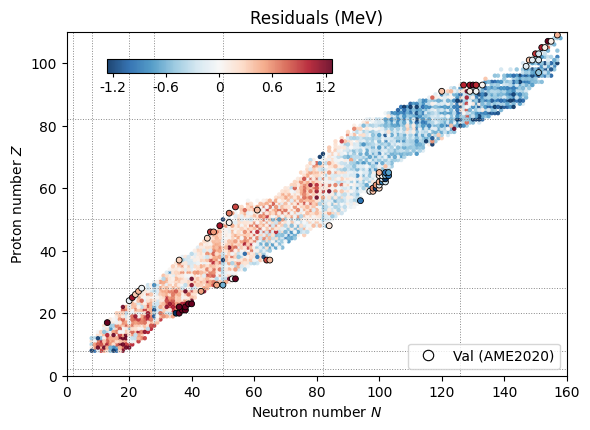


--- LDM+SU(4)+SU(3) / PINN / PReLU / 2.0 ---


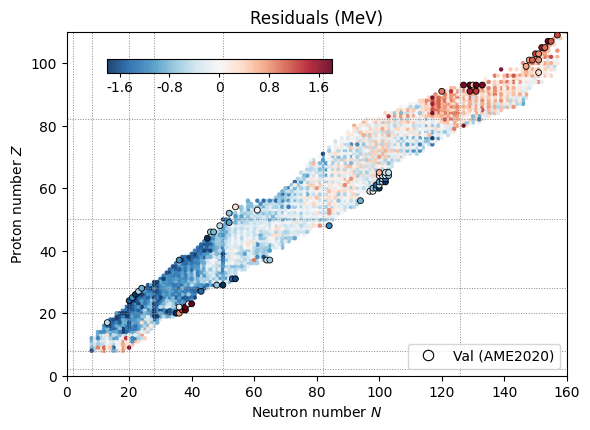


--- LDM+SU(4)+SU(3) / PINN / PReLU / 4.0 ---


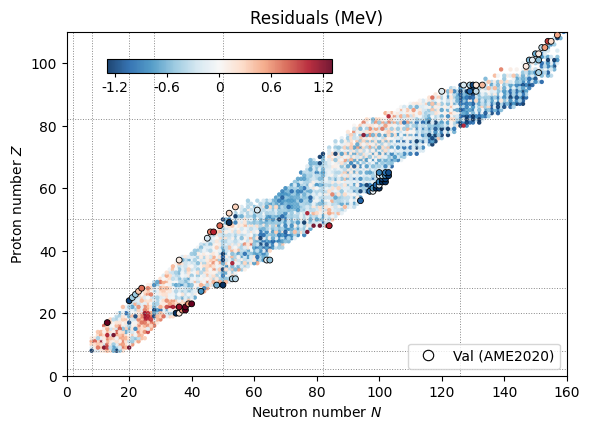


--- LDM+SU(4)+SU(3) / PINN / ReLU / 1.0 ---


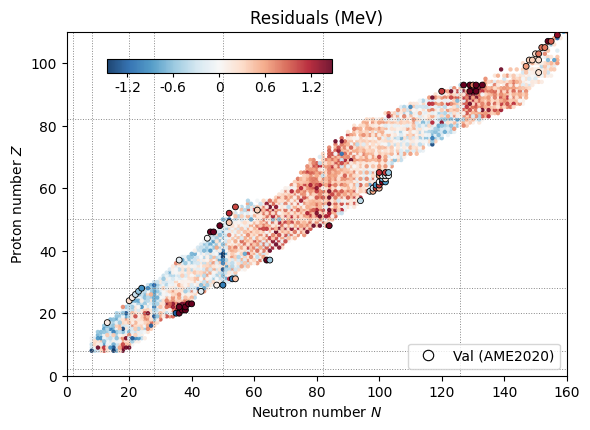


--- LDM+SU(4)+SU(3) / PINN / ReLU / 2.0 ---


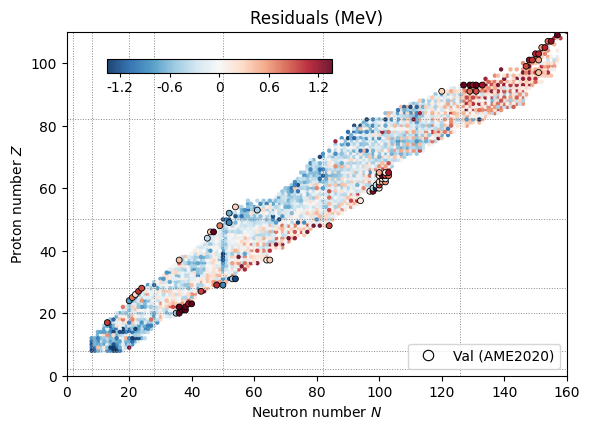


--- LDM+SU(4)+SU(3) / PINN / ReLU / 4.0 ---


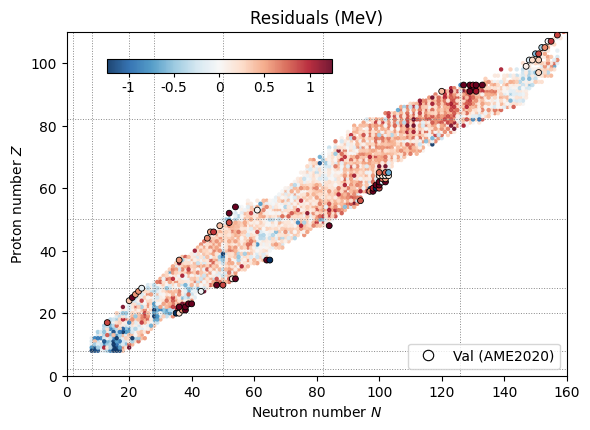

In [10]:
for feat_name in FEATURE_SETS:
    for act_name, act_factory in activations.items():
        for GK in GK_LAMBDA:
            _, norm, metrics, tensors = results[(feat_name, 'PINN', act_name, GK)]
            X_tr_, X_te_, X_v_, _, _, _ = tensors
            print(f'\n--- {feat_name} / PINN / {act_name} / {GK} ---')
            symass.plot_predictions(
                metrics['train'], metrics['test'],
                tr_N=N_all[tr], tr_Z=Z_all[tr],
                te_N=N_all[te], te_Z=Z_all[te],
                val_metrics=metrics['val'],
                val_N=N_all[val], val_Z=Z_all[val],
                true_vs_pred=False
            )

## 9 — SHAP feature importance

SHAP values quantify each feature's average contribution to the prediction.
Comparing the bar charts shows
which features the network actually uses and how importance redistributes
as the feature set grows.


--- SHAP: LDM+SU(4)+SU(3) / PReLU / 1.0 ---


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:597: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


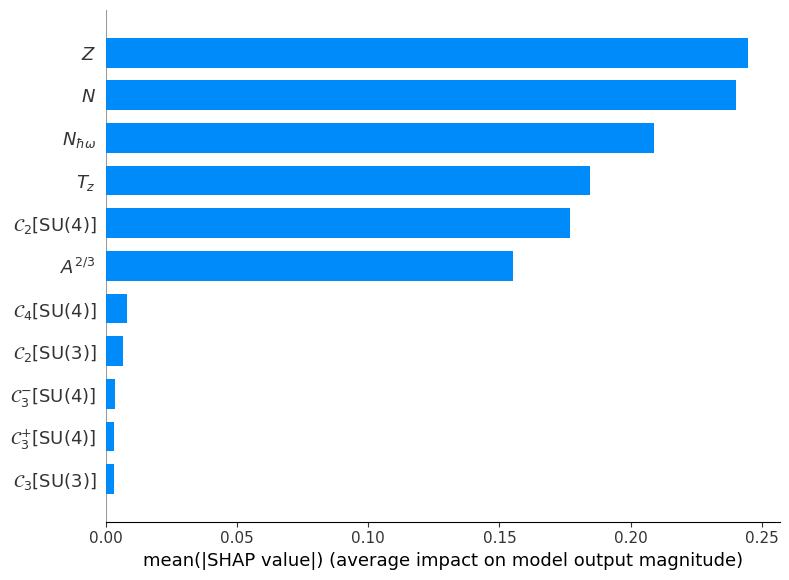

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:609: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


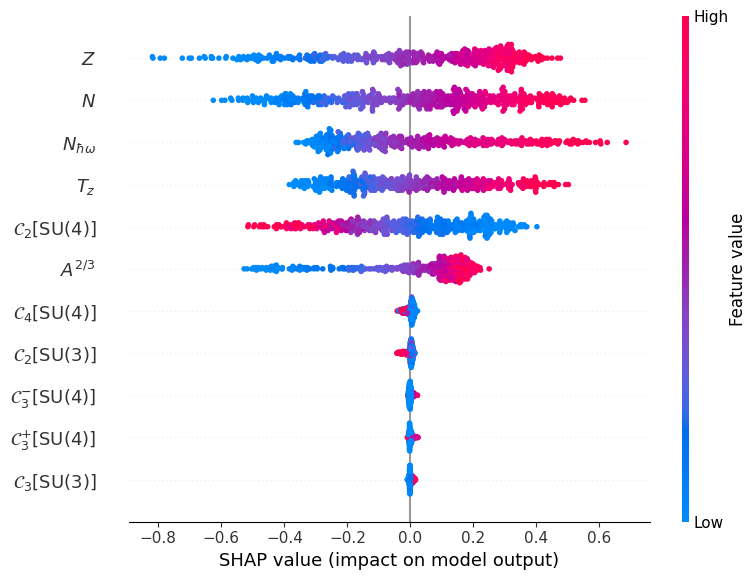


--- SHAP: LDM+SU(4)+SU(3) / PReLU / 2.0 ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:597: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


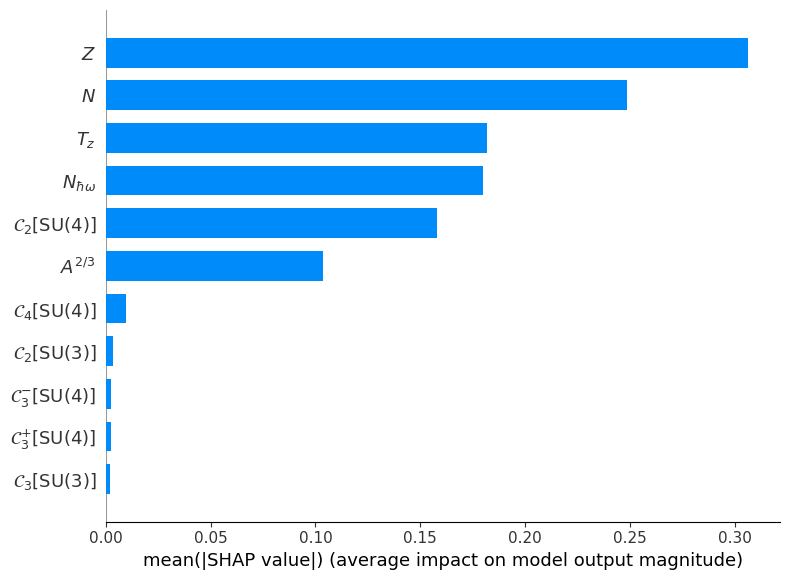

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:609: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


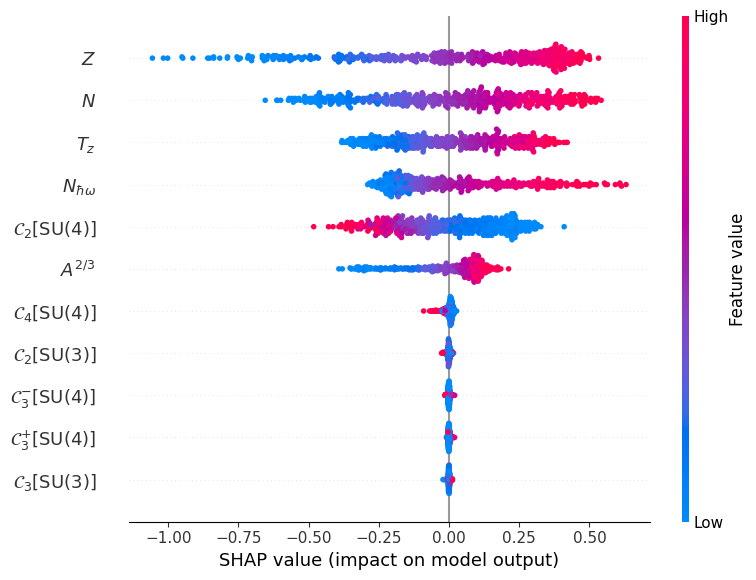


--- SHAP: LDM+SU(4)+SU(3) / PReLU / 4.0 ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:597: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


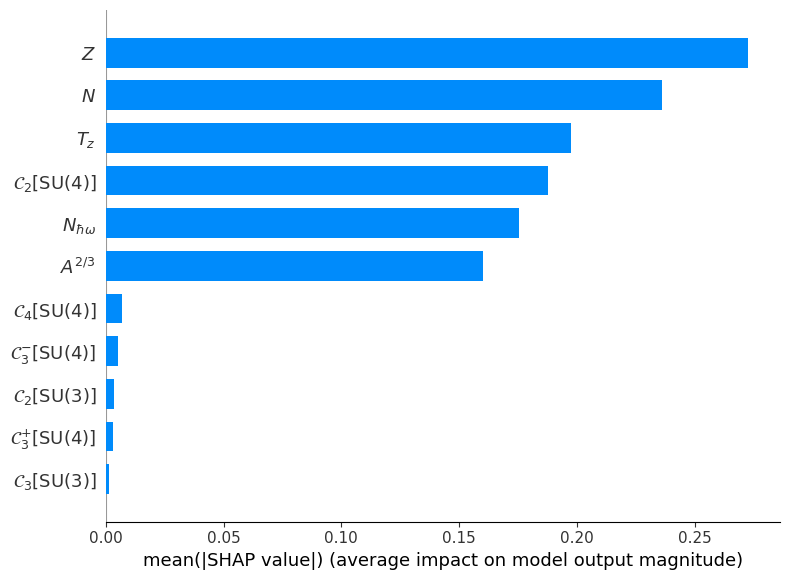

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:609: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


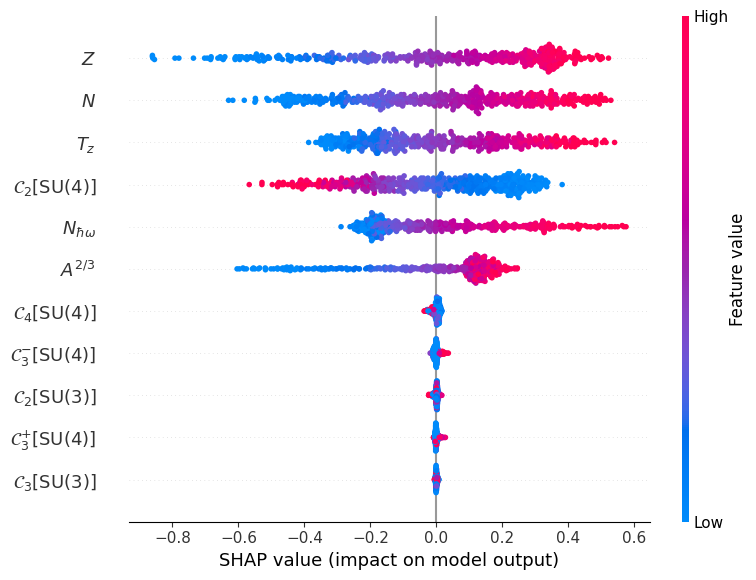


--- SHAP: LDM+SU(4)+SU(3) / ReLU / 1.0 ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:597: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


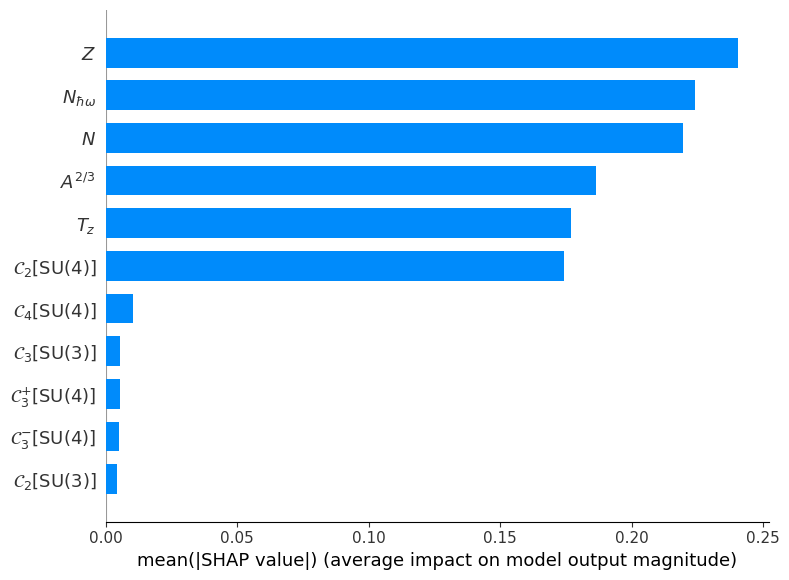

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:609: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


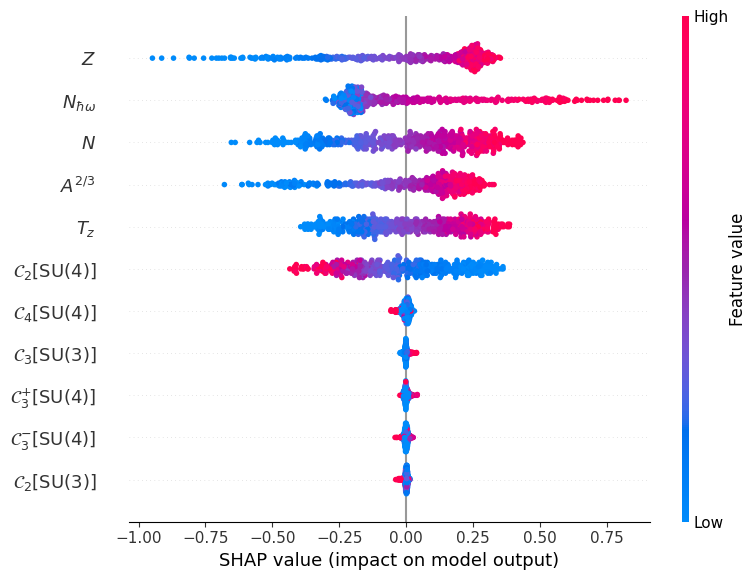


--- SHAP: LDM+SU(4)+SU(3) / ReLU / 2.0 ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:597: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


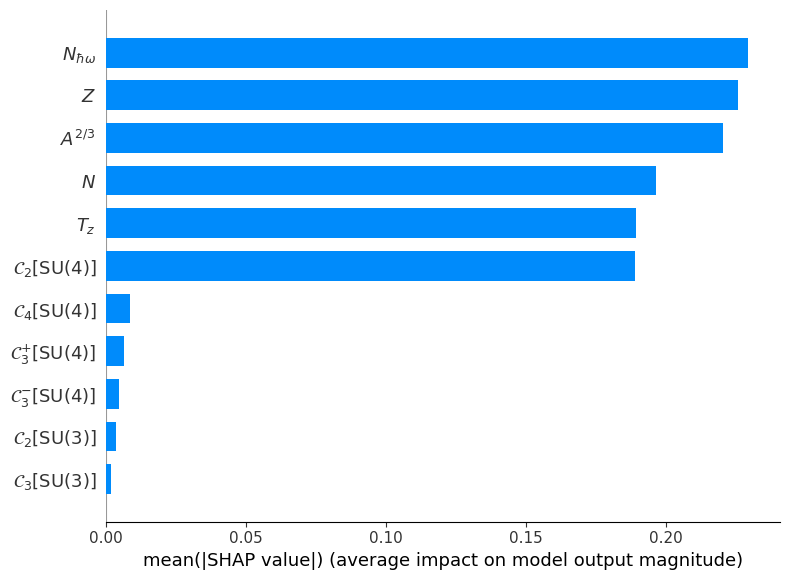

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:609: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


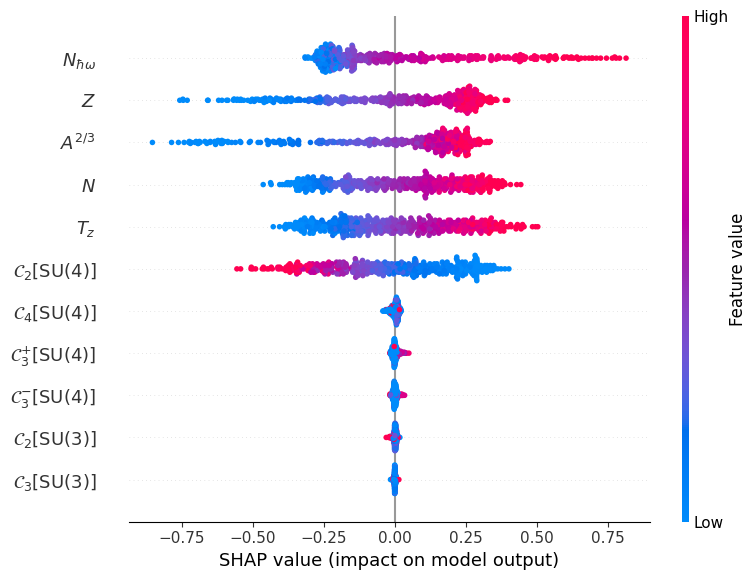


--- SHAP: LDM+SU(4)+SU(3) / ReLU / 4.0 ---


/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:597: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


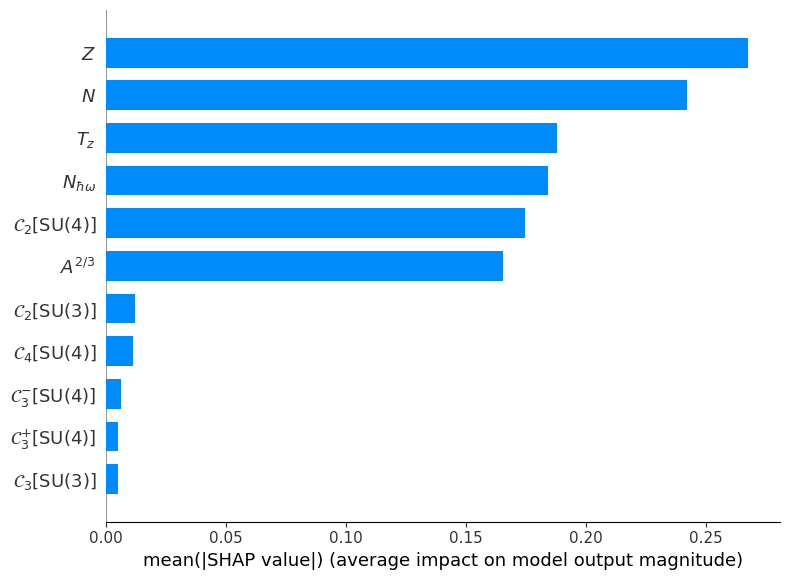

/Users/phongdang/Desktop/Wigner-mass/symass/plot.py:609: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


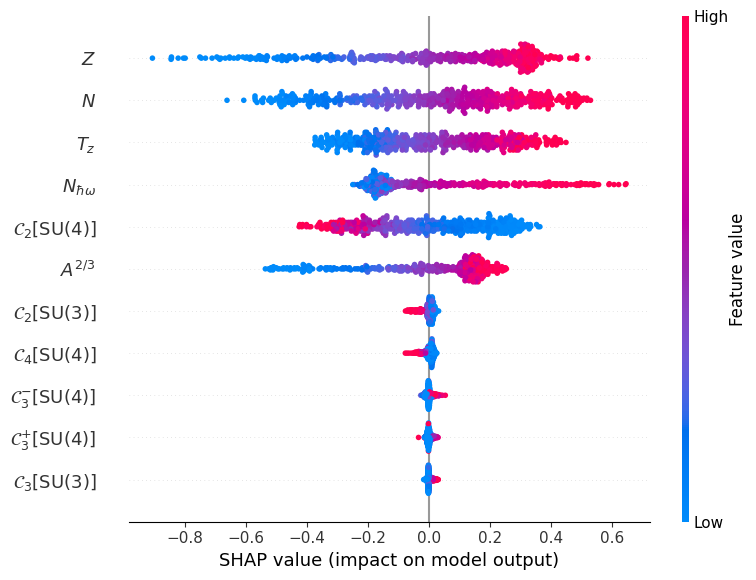

In [9]:
for feat_name in FEATURE_SETS:
    for act_name, act_factory in activations.items():
        for GK in GK_LAMBDA:
            model, norm, _, tensors = results[(feat_name, 'PINN', act_name, GK)]
            X_tr_, X_te_, *_ = tensors
            feats = FEATURE_SETS[feat_name]
            print(f'\n--- SHAP: {feat_name} / {act_name} / {GK} ---')
            symass.plot_shap(model, X_tr_, X_te_, feats)